In [ ]:
'''23) Association Rule mining datasets_Market_Basket_Optimisation
Using this record of transactions and items in each transaction, find the association rules between items.
There is no header in the dataset and the first row contains the first transaction, so mentioned header = None here while loading dataset.
Follow following steps :
Data Preprocessing
Generate the list of transactions from the dataset
Train Apriori algorithm on the dataset
Visualize the list of rules'''

'23) Association Rule mining datasets_Market_Basket_Optimisation\nUsing this record of transactions and items in each transaction, find the association rules between items.\nThere is no header in the dataset and the first row contains the first transaction, so mentioned header = None here while loading dataset.\nFollow following steps :\nData Preprocessing\nGenerate the list of transactions from the dataset\nTrain Apriori algorithm on the dataset\nVisualize the list of rules'

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("Association Rule mining datasets_Market_Basket_Optimisation.csv",header=None)
'''header=None means the CSV file has no column names (since each row is just a list of items).
each row= 1 Transaction'''
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,butter,light mayo,fresh bread,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7497,burgers,frozen vegetables,eggs,french fries,magazines,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7498,chicken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7499,escalope,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Drop completely empty rows
dataset = df.dropna(how='all')


# Convert rows to lists without NaN values
transactions = dataset.apply(lambda x: x.dropna().astype(str).tolist(), axis=1).tolist()
'''dropna(how='all') removes rows that are completely empty.

.apply(lambda x: …) converts each row into a list of non-empty items.

transactions is now a list of lists — format required for Apriori.'''

"dropna(how='all') removes rows that are completely empty.\n\n.apply(lambda x: …) converts each row into a list of non-empty items.\n\ntransactions is now a list of lists — format required for Apriori."

In [ ]:
print("Total Transactions:", len(transactions))
print("Sample Transaction:", transactions[0])

Total Transactions: 7501
Sample Transaction: ['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']


In [ ]:
# Applying Apriori
# min_support=0.003 means item appears in at least 0.3% of transactions
# min_confidence=0.2 means 20% confidence
# min_lift=3 filters strong associations
# min_length=2 ensures at least two items in rule
'''Explanation:
pandas → to handle dataset
matplotlib → to visualize results
apyori → provides Apriori algorithm implementation'''
from apyori import apriori
rules = apriori(transactions,
                min_support=0.003,        #min_support filters out infrequent items.
                min_confidence=0.2,                     # min_confidence ensures reliable associations.
                min_lift=3,                       # min_lift keeps only strong, meaningful rules.
                min_length=2)                        # min_length ensures that at least 2 items are involved.'''

# Convert rules generator to list
results = list(rules)



In [ ]:
# Make rules easy to read
simple_rules = []

for rule in results: #
# This loops through each association rule that the Apriori algorithm generated and stored in results.
# Each rule contains :
# support: how often the combination appears in the dataset.
# ordered_statistics: details of the rule in "if–then" form.


    for stat in rule.ordered_statistics: #  # Only take rules where both sides (base → add) are not empty
        if len(stat.items_base) > 0 and len(stat.items_add) > 0:
            simple_rules.append([
                list(stat.items_base)[0],   # Left-hand side item
                list(stat.items_add)[0],   # Right-hand side item
                round(rule.support, 3),
                round(stat.confidence, 3),
                round(stat.lift, 3)
            ])
'''Each rule contains combinations of items and metrics.
We extract only LHS (base item) and RHS (added item) for simplicity.
Lift shows how strongly items are associated.'''
# Create DataFrame
rules_df = pd.DataFrame(simple_rules, columns=['LHS', 'RHS', 'Support', 'Confidence', 'Lift'])

# Sort and show top 10
rules_df = rules_df.sort_values(by='Lift', ascending=False)
print(rules_df.head(10))


                   LHS            RHS  Support  Confidence   Lift
107               soup  mineral water    0.003       0.383  7.987
103          olive oil  mineral water    0.003       0.294  6.128
69   whole wheat pasta      olive oil    0.004       0.403  6.116
108               soup  mineral water    0.003       0.202  5.647
56        tomato sauce    ground beef    0.003       0.217  5.536
109      mineral water           soup    0.003       0.277  5.484
3        fromage blanc          honey    0.003       0.245  5.164
58        tomato sauce    ground beef    0.003       0.489  4.981
0          light cream        chicken    0.005       0.291  4.844
2                pasta       escalope    0.006       0.373  4.701


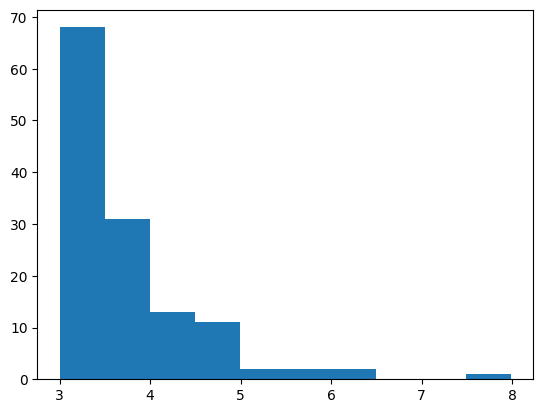

In [ ]:
import matplotlib.pyplot as plt
plt.hist(rules_df['Lift'])
plt.title('Distribution of Lift Values')
#plt.xlabel('Lift')
#plt.ylabel('Number of Rules')
plt.show()

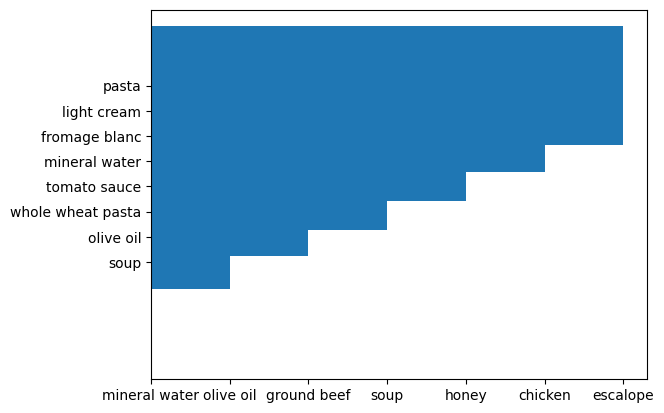

In [ ]:

top_rules = rules_df.sort_values(by='Lift', ascending=False).head(10)
plt.barh(top_rules['LHS'] , top_rules['RHS'], top_rules['Lift'])
plt.xlabel('Lift')
plt.ylabel('Rule')
plt.title('Top 10 Association Rules')
plt.show()


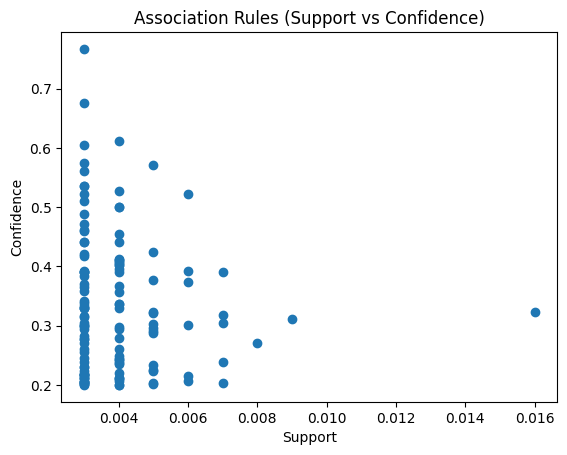

In [ ]:

plt.scatter(rules_df['Support'], rules_df['Confidence'])
plt.title('Association Rules (Support vs Confidence)')
# plt.xlabel('Support')
#plt.ylabel('Confidence')
plt.show()
